# Application of WAVEGUISE to a 25-day pressure time series from the Strateole-2 campaign
During the Strateole-2 campaign long-duration superpressure balloons equipped with a number of sensors was floating at equatorial latitudes. At an altitude of approximately 50hPa the balloon was sampling temperature, pressure, wind, humidity, etc. I'm investigating the pressure data and aim to separate periodic structures from gravity waves, tides, and planetary waves. Simultaneously, the spectral properties of the identified wave packets are extracted.

This notebook also serves to generate Figure 2 in Reichert et al. submitted to AMT.

### Overview of functions in use
**waveguise** contains:
- **utils_1d.BG_removal()**: Splits the data into a low-frequency background and high frequency wave field.
- **utils_1d.denoise_1d()**: Denoises the data.
- **utils_1d.wavefield_segmentation_1d()**: Provides labels that group wave packets in the wavelet amplitude spectrum.
- **utils_1d.find_clusters_in_freq()**: Joins segments that share spectral properties.
- **utils_1d.build_cluster_map_with_noise()**: Builds a map from previous labels to new labels
- **utils_1d.relabel_by_x_overlap()**: Separates segments again if they do not overlap.
- **utils_1d.variance_filter()**: Filters wave packets that do not contribute much variance.
- **utils_1d.recon_WP_and_properties_1d()**: Reconstructs the wave packets and computes instantaneous spectral properties.

**juwavelet** contains:
- **utils.smooth_edges()**: Tapers the data set to suppress edge effects in the spectral analysis. 
- **transform.decompose1d()**: Computes the continuous wavelet transform of a signal.

In [1]:
import sys
sys.path.append('/home/r/Robert.Reichert/juwavelet')
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_1d as one

import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
ST2_path = '../data/ST2_C0_01_STR1_TSEN_v03b.nc'
ds = xr.open_dataset(ST2_path)
# We stick to the first 25 days of the measurements since there is an inconvenient spike in the time series.
ds = ds.isel(time=slice(0,600*60*2))

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
# Background Removal with polynomial degree 1 and Fourier coefficients up to 1.
dt, nt        = 30/3_600, len(ds['time']) #[h]
time          = np.linspace(dt,nt*dt,nt)
orig          = ds['pressure'].values.copy()
p_high, p_low = one.BG_removal(orig,max_order=1)

# The outer 10% of the data are tapered.
nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(p_high, ntap, window='tukey')

# Define parameters for the CWT.
s0 = 20 #smallest scale that we wanna resolve
s1 = nt #largest scale is the domain size
dj = 1/8
js = int(1/dj*np.log2(s1/s0))
cwt_result = transform.decompose1d(signal, dt, s0 * dt, dj, js, opts={'param': 2*np.pi}, mode="scaled", dtype=np.complex128)

# Denoising
noise_level = 0.1 #units of hPa see Corcos et al. (2021)
wavy_stuff, denoised_cwt = one.denoise_1d(cwt_result,white_noise_level=4*noise_level) #the empirical factor of ~4 results in sufficient noise reduction

params = {
    "Data size": f"{signal.size:.0f}",
    "Smallest scale (s0)": f"{s0:.0f}",
    "Largest scale (s1)": f"{s1:.0f}",
    "Scale sampling (dj)": f"{dj:.3f}",
    "Number of scales (js)": f"{js:.0f}",
    "Non-dimensional frequency": f"{cwt_result['opts']['param']:.2f}",
    "Noise level": f"{noise_level:.1f}",
}
label_width = max(len(label) for label in params)
for label, value in params.items():
    print(f"{label:<{label_width}} : {value}")

Data size                 : 72000
Smallest scale (s0)       : 20
Largest scale (s1)        : 72000
Scale sampling (dj)       : 0.125
Number of scales (js)     : 94
Non-dimensional frequency : 6.28
Noise level               : 0.1


Text(0.03, 0.94, 'c')

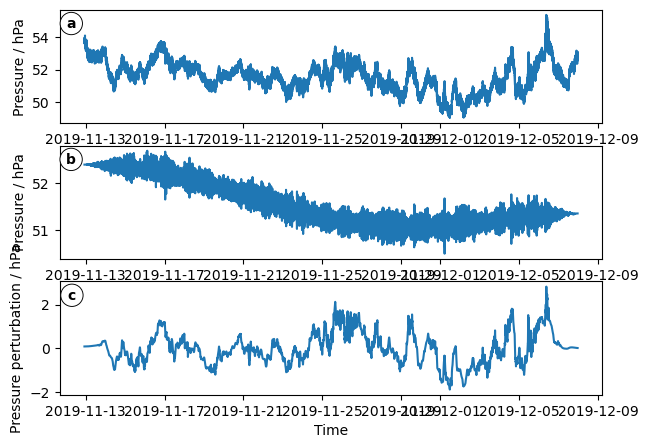

In [4]:
fig=plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
ax1.plot(ds['time'],ds['pressure'].values)
ax2 = fig.add_subplot(312)
ax2.plot(ds['time'],p_low+signal-wavy_stuff+np.mean(ds['pressure'].values))
ax3 = fig.add_subplot(313)
ax3.plot(ds['time'],wavy_stuff)

ax1.set_ylabel('Pressure / hPa')
ax2.set_ylabel('Pressure / hPa')
ax3.set_ylabel('Pressure perturbation / hPa')
ax3.set_xlabel('Time')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

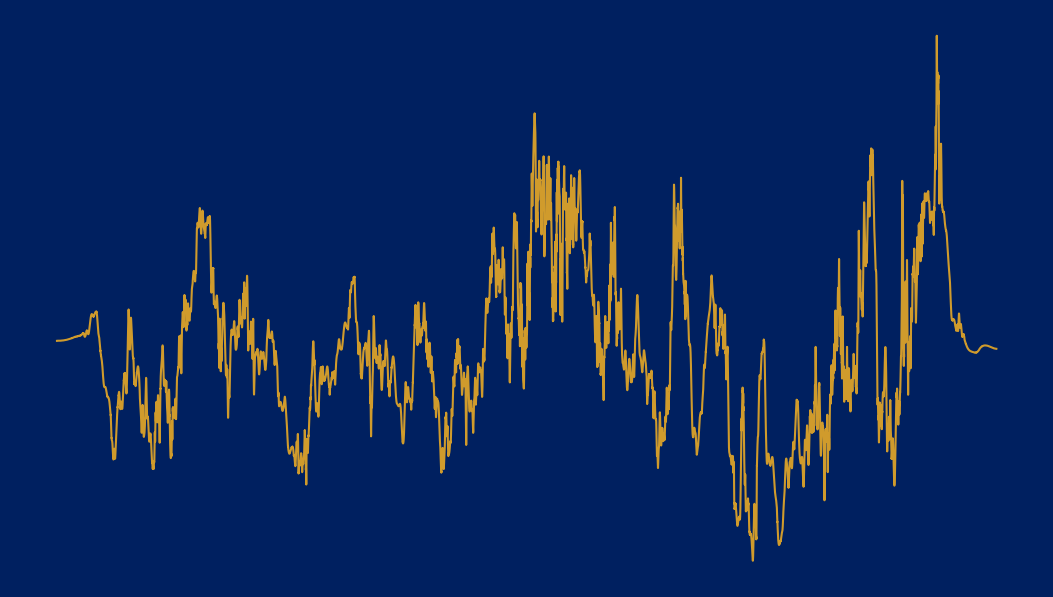

In [11]:
fig=plt.figure(figsize=(13.333,7.5))
ax=fig.add_subplot()
fig.patch.set_facecolor('#002060')
ax.plot(ds['time'],wavy_stuff,c='#D09B2C')
ax.axis('off')
ax.set_facecolor('#002060')
plt.savefig('./figures/1D_Strateole-2_COSPAR.png',dpi=150,bbox_inches="tight",pad_inches=0.00)

## Segmentation

In [8]:
WAS        = np.abs(denoised_cwt['decomposition'])
seg_v1     = one.wavefield_segmentation_1d(WAS,0.01,connectivity_order=1)
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels      = np.arange(1,np.max(seg_v1)+1)
k     = 2*np.pi/cwt_result['period']
eps   = 1.01*np.abs(np.diff(np.log(k)))[0]
cluster_labels = one.find_clusters_in_freq(denoised_cwt, seg_v1, eps=eps)
cluster_map    = one.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = one.relabel_by_x_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))
seg_v3         = one.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 272 initial wave packets!
Reduced the number of wave packets to 27
Final number of wave packets: 8


## Reconstruction

In [12]:
recon_seg, amp_seg, freq_seg = one.recon_WP_and_properties_1d(denoised_cwt,seg_v3)

In [6]:
def get_distinct_colors(n, saturation=0.75, value=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [mcolors.hsv_to_rgb((h, saturation, value)) for h in hues]
    return colors

def darken(color, factor=0.8):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

def compute_offsets(wavy_stuff, amp_seg):
    base = -np.max(np.abs(wavy_stuff))
    offsets = []
    cumulative = 0.0

    for seg in amp_seg:
        current = base - cumulative - 2*np.max(seg)
        offsets.append(current)
        cumulative += 2*np.max(seg)

    return np.array(offsets)

/scratch-local/slurm-job-tmp-14985722/ipykernel_383/3006674629.py:1: RuntimeWarning: divide by zero encountered in divide
  per_seg = 2*np.pi/freq_seg


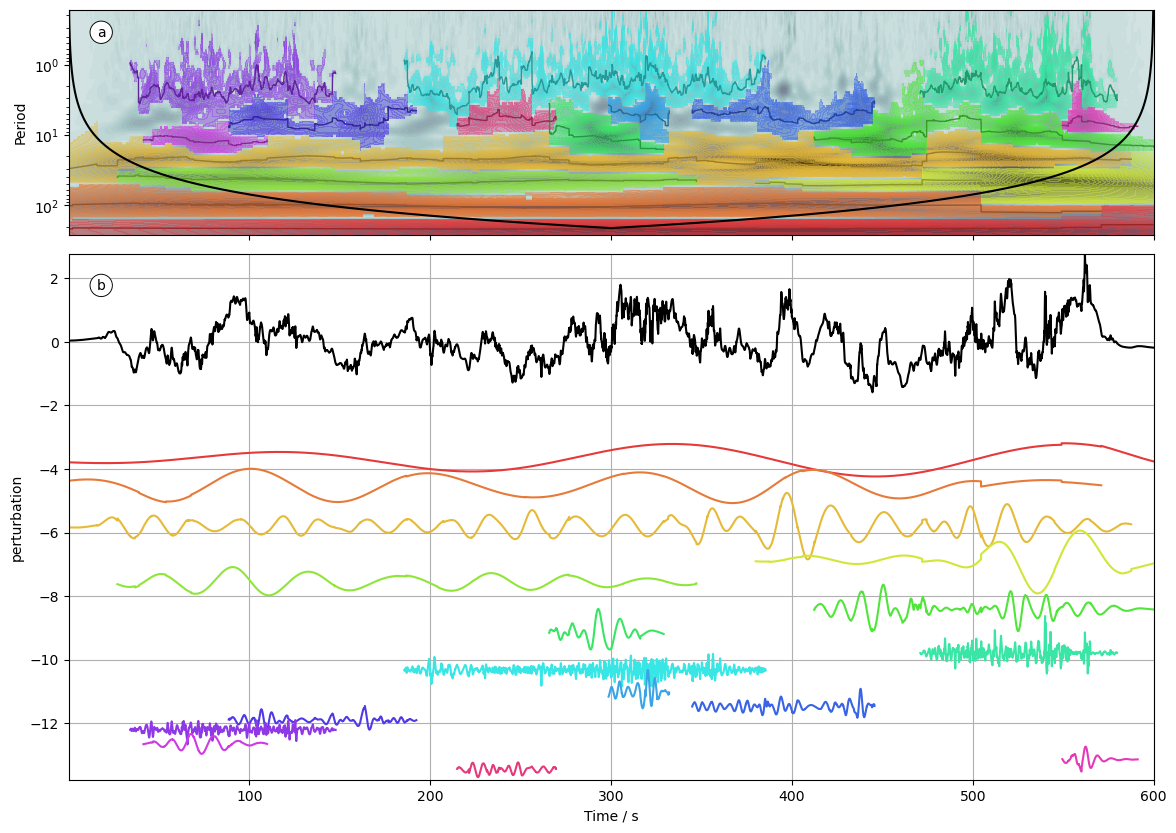

In [13]:
per_seg = 2*np.pi/freq_seg
WAS = np.abs(cwt_result['decomposition'])

N_waves = np.max(seg_v3)
colors  = get_distinct_colors(N_waves)

TIME, PERIOD = np.meshgrid(time, cwt_result["period"])

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1], "height_ratios": [3,7]}

fig, ax=plt.subplots(2, 1, figsize=(14,10), gridspec_kw=gskw, sharex=True)

plot_WAS = ax[0].contourf(TIME, PERIOD, WAS, levels=np.linspace(-0.1,np.max(WAS),51), cmap='bone_r')
ax[0].set_yscale("log")
ax[0].set_ylabel("Period")
ax[0].set_ylim([np.max(cwt_result['period']),np.min(cwt_result['period'])])

ax[1].tick_params(which="both", labelbottom=True, labeltop=False)
ax[1].set_xlabel('Time / s')

for lab in np.unique(seg_v3):
    if lab == 0:
        continue
    mask     = (seg_v3 == lab)
    if not np.any(mask):
        continue

    # Create a noise WAS as proper reference
    noise = np.random.normal(0,noise_level,len(time))
    noise_cwt = transform.decompose1d(noise, dt, s0, dj, js, opts={'param': 2*np.pi}, mode='scaled', dtype=np.complex128)
    noise_WAS = one.get_noise_WAS(noise_cwt['scale'],np.mean(np.abs(noise_cwt['decomposition']),axis=1))

    mask = (seg_v3 == lab) & (WAS > noise_WAS[:,None])
    masked_WAS = np.ma.masked_where(~mask, WAS)
    # Base color
    base = mcolors.to_rgb(colors[lab-1])
    
    # Create custom colormap: white -> orange -> black
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_orange_black",
        [(0.0, base),(0.5, base),(1.0, base)]
    )
    ax[0].contourf(TIME, PERIOD, masked_WAS, levels=np.linspace(0,np.max(WAS),51), cmap=cmap, alpha=0.4)
    ax[0].plot(time, per_seg[lab-1,:], c=darken(colors[lab-1],factor=0.67), linewidth=1)

x2 = time
order=2*np.pi
coi_x = np.minimum(x2,x2[-1]-x2)
coi_boundary_scale = coi_x / np.sqrt(2)
coi_boundary_wavelength = 4*np.pi*coi_boundary_scale/(order+np.sqrt(2+order**2))
ax[0].plot(time, coi_boundary_wavelength, c='k')

offset = compute_offsets(wavy_stuff,amp_seg)

# ORIGINAL
ax[1].plot(time, wavy_stuff, c='k', label='original')
ax[1].set_ylabel('perturbation')
ax[1].set_ylim([2*offset[-1]-offset[-2],np.max(np.abs(wavy_stuff))])

for idx in range(N_waves):
    ax[1].plot(time,np.where(amp_seg[idx]==0,np.nan,recon_seg[idx]+offset[idx]),c=colors[idx])

ax[0].text(0.03,0.9,'a',va='center', ha='center', bbox=letterbox, transform=ax[0].transAxes)
ax[1].text(0.03,0.94,'b',va='center', ha='center', bbox=letterbox, transform=ax[1].transAxes)
ax[1].grid(which='both')

## Create figure for publication

In [37]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.signal import find_peaks
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.dates as mdates
import plot_tools as pt

plt.style.use("../latex_default_AMT.mplstyle")

Text(0.03, 0.94, 'c')

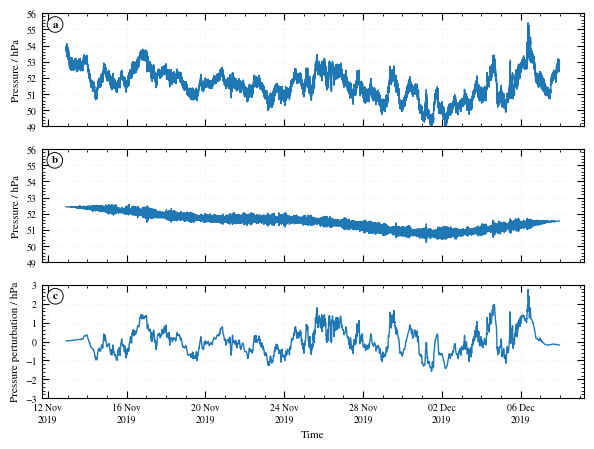

In [24]:
fig=plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
ax1.plot(ds['time'],ds['pressure'].values)
ax2 = fig.add_subplot(312)
ax2.plot(ds['time'],p_low+signal-wavy_stuff+np.mean(ds['pressure'].values))
ax3 = fig.add_subplot(313)
ax3.plot(ds['time'],wavy_stuff)
#ax3.plot(ds['time'],recon_domi)
ax1.set_ylim([49,56])
ax2.set_ylim([49,56])
ax3.set_ylim([-3,3])

ax1.set_ylabel('Pressure / hPa')
ax2.set_ylabel('Pressure / hPa')
ax3.set_ylabel('Pressure perturbation / hPa')

hlocator = mdates.DayLocator(interval=4)
hformatter = mdates.DateFormatter('%d %b\n%Y')
minorlocator = mdates.DayLocator(interval=1)

for a in [ax1,ax2,ax3]:
    a.xaxis.set_major_locator(hlocator)
    a.xaxis.set_major_formatter(hformatter)
    a.xaxis.set_minor_locator(minorlocator)

ax1.yaxis.set_major_locator(MultipleLocator(1))
ax2.yaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.set_major_locator(MultipleLocator(1))
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax3.yaxis.set_minor_locator(AutoMinorLocator())

ax1.tick_params(which="both", labelbottom=False, labeltop=False)
ax2.tick_params(which="both", labelbottom=False, labeltop=False)
ax3.tick_params(which="both", labelbottom=True, labeltop=False)
ax3.set_xlabel('Time')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/1D_Strateole-2_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

<>:120: SyntaxWarning: invalid escape sequence '\p'
<>:120: SyntaxWarning: invalid escape sequence '\p'
/scratch-local/slurm-job-tmp-14985722/ipykernel_383/476880810.py:120: SyntaxWarning: invalid escape sequence '\p'
  ax[1].text(ds['time'][mask][int(np.sum(mask)/2)],np.max(amp_seg[idx][mask])+offset[idx],f"{np.mean(per_seg[idx][mask]):.0f}$\pm${np.std(per_seg[idx][mask]):.0f}h", va='bottom', ha='left', bbox=titlebox, size=font_size)
/scratch-local/slurm-job-tmp-14985722/ipykernel_383/476880810.py:1: RuntimeWarning: divide by zero encountered in divide
  per_seg      = 2*np.pi/freq_seg
/scratch-local/slurm-job-tmp-14985722/ipykernel_383/476880810.py:130: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from font(s) STIXGeneral.
  plt.savefig('./figures/1D_Strateole-2_v3.png',dpi=300,bbox_inches="tight",pad_inches=0.03) # for publication
/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8239 (\N{NARR

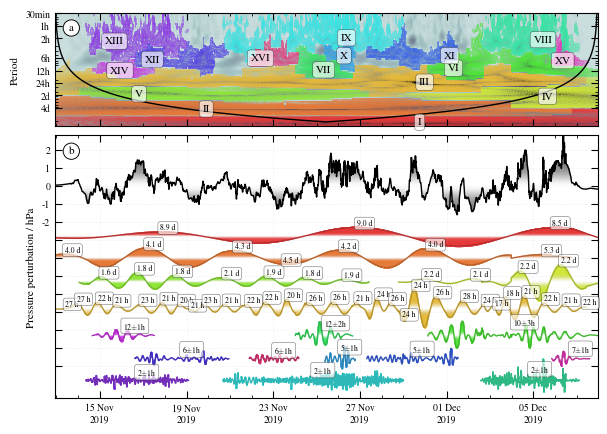

In [38]:
per_seg      = 2*np.pi/freq_seg
TIME, PERIOD = np.meshgrid(ds['time'], cwt_result["period"])
WAS          = np.abs(cwt_result['decomposition'])

font_size='x-small'
short_labels = ['I','II','III','IV','V','VI','VII','VIII','IX','X','XI','XII','XIII','XIV','XV','XVI']
#colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:olive','tab:cyan','tab:gray','coral']
N_waves = np.max(seg_v3)
colors  = pt.get_distinct_colors(N_waves)
dark_colors = [pt.darken(c, 0.8) for c in colors]
titlebox = {"boxstyle": "round", "lw": 0.33, "facecolor": "white", "edgecolor": "black", "alpha": 0.67}
letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1], "height_ratios": [3,7]}
"""
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
"""
fig, ax=plt.subplots(2, 1, figsize=(7,5), gridspec_kw=gskw, sharex=True) #for publication
#fig, ax=plt.subplots(2, 1, figsize=(13.333,7.5), gridspec_kw=gskw, sharex=True) #for presentation

ax[0].contourf(TIME, PERIOD, WAS, levels=np.linspace(-0.1,0.6,51), extend='max', cmap='bone_r')
ax[0].set_yscale("log")
ax[0].set_ylabel("Period")
ax[0].set_yticks([0.5,1,2,6,12,24,48,4*24,11*24],['30min','1h','2h','6h','12h','24h','2d','4d','11d'])
ax[0].set_ylim([np.max(cwt_result['period']),0.5])

hlocator = mdates.DayLocator(interval=4)
hformatter = mdates.DateFormatter('%d %b\n%Y')
minorlocator = mdates.DayLocator(interval=1)

for a in ax:
    a.xaxis.set_major_locator(hlocator)
    a.xaxis.set_major_formatter(hformatter)
    a.xaxis.set_minor_locator(minorlocator)

ax[1].tick_params(which="both", labelbottom=True, labeltop=False)

# Create a noise WAS as proper reference
noise = np.random.normal(0,noise_level,len(time))
noise_cwt = transform.decompose1d(noise, dt, s0, dj, js, opts={'param': 2*np.pi}, mode='scaled', dtype=np.complex128)
noise_WAS = one.get_noise_WAS(noise_cwt['scale'],np.mean(np.abs(noise_cwt['decomposition']),axis=1))

for lab in np.unique(seg_v3):
    if lab == 0:
        continue
    mask     = (seg_v3 == lab)
    if not np.any(mask):
        continue
        
    mask = (seg_v3 == lab) & (WAS > noise_WAS[:,None])
    
    bla = freq_seg[lab-1,:]>0
    y0 = np.mean(per_seg[lab-1,bla])
    masked_WAS = np.ma.masked_where(~mask, WAS)
    # Base color
    base = mcolors.to_rgb(colors[lab-1])
    
    # Create custom colormap: white -> orange -> black
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_orange_black",
        [
            (0.0, base),   # white
            (0.5, base),        # tab:orange
            (1.0, base)    # black
        ]
    )
    ax[0].contourf(TIME, PERIOD, masked_WAS, levels=np.linspace(0,0.6,51), cmap=cmap, alpha=0.4)
    x0=np.argmax(amp_seg[lab-1,:])
    ax[0].text(ds['time'].isel(time=x0),y0,short_labels[lab-1],va='center', ha='center', bbox=titlebox)

x2 = time
order=2*np.pi
coi_x = np.minimum(x2,x2[-1]-x2)
coi_boundary_scale = coi_x / np.sqrt(2)
coi_boundary_wavelength = 4*np.pi*coi_boundary_scale/(order+np.sqrt(2+order**2))
ax[0].plot(ds['time'], coi_boundary_wavelength, c='k')

# ORIGINAL
ax[1].plot(ds['time'], wavy_stuff, c='k')
max_amp = np.nanmax(np.abs(wavy_stuff))
n_layers = 50  # Anzahl der Gradient-Stufen
for i in range(n_layers):
    alpha = (i + 1) / n_layers
    ax[1].fill_between(ds['time'], wavy_stuff, y2=max_amp*alpha, where=wavy_stuff>max_amp*alpha, color='grey', alpha=alpha*0.5)
    ax[1].fill_between(ds['time'], wavy_stuff, y2=-max_amp*alpha, where=wavy_stuff<-max_amp*alpha, color='grey', alpha=alpha*0.5)

ax[1].set_ylabel('Pressure perturbation / hPa')
ax[1].set_xlabel('')
ax[1].set_ylim([-11.8,2.8])
ax[1].set_yticks([-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2],['','','','','','','','','-2','-1','0','1','2'])

offset = [-2.8, -4.0, -6.8, -5.3, -5.3, -8.3, -8.3, -10.8, -10.8, -9.6, -9.6, -9.6, -10.8, -8.3, -9.6, -9.6]
dist = [11*24/dt/2, 96/dt/2, 24/dt/2, 48/dt/2, 48/dt/2]
n_wave = 5
for idx in range(n_wave):

    peaks, _ = find_peaks(recon_seg[idx],distance=dist[idx])
    ax[1].plot(ds['time'],np.where(amp_seg[idx]==0,np.nan,recon_seg[idx]+offset[idx]),c=dark_colors[idx])
    for label in peaks:
        if idx == 2:
            ax[1].text(ds['time'][label],recon_seg[idx][label]+offset[idx],f"{per_seg[idx][label]:.0f}\u202Fh", va='bottom', ha='left', bbox=titlebox, size=font_size)
        else:
            ax[1].text(ds['time'][label],recon_seg[idx][label]+offset[idx],f"{per_seg[idx][label]/24:.1f}\u202Fd", va='bottom', ha='left', bbox=titlebox, size=font_size)

    max_amp = np.nanmax(np.abs(recon_seg[idx]))
    for i in range(n_layers):
        alpha = (i + 1) / n_layers
        ax[1].fill_between(ds['time'], recon_seg[idx]+offset[idx], y2=offset[idx]+max_amp*alpha, where=recon_seg[idx]>max_amp*alpha, color=colors[idx], alpha=alpha*0.5)
        ax[1].fill_between(ds['time'], recon_seg[idx]+offset[idx], y2=offset[idx]-max_amp*alpha, where=recon_seg[idx]<-max_amp*alpha, color=colors[idx], alpha=alpha*0.5)

for idx in range(5,16):
    ax[1].plot(ds['time'],np.where(amp_seg[idx]==0,np.nan,recon_seg[idx]+offset[idx]),c=dark_colors[idx])
    mask = amp_seg[idx] > 0
    ax[1].text(ds['time'][mask][int(np.sum(mask)/2)],np.max(amp_seg[idx][mask])+offset[idx],f"{np.mean(per_seg[idx][mask]):.0f}$\pm${np.std(per_seg[idx][mask]):.0f}h", va='bottom', ha='left', bbox=titlebox, size=font_size)
    max_amp = np.nanmax(np.abs(recon_seg[idx]))
    for i in range(n_layers):
        alpha = (i + 1) / n_layers
        ax[1].fill_between(ds['time'], recon_seg[idx]+offset[idx], y2=offset[idx]+max_amp*alpha, where=recon_seg[idx]>max_amp*alpha, color=colors[idx], alpha=alpha*0.5)
        ax[1].fill_between(ds['time'], recon_seg[idx]+offset[idx], y2=offset[idx]-max_amp*alpha, where=recon_seg[idx]<-max_amp*alpha, color=colors[idx], alpha=alpha*0.5)

ax[0].text(0.03,0.87,'a',va='center', ha='center', bbox=letterbox, transform=ax[0].transAxes)
ax[1].text(0.03,0.94,'b',va='center', ha='center', bbox=letterbox, transform=ax[1].transAxes)

plt.savefig('./figures/1D_Strateole-2_v3.png',dpi=300,bbox_inches="tight",pad_inches=0.03) # for publication
#plt.savefig('./figures/1D_Strateole-2_v3_talk.png',dpi=150,bbox_inches="tight",pad_inches=0.05) #for presentation

In [12]:
# Using the standard analyze2d_dominant() function retrieves dominant waves for each pixel.
WAS = np.abs(denoised_cwt['decomposition'])
recon_domi = np.zeros_like(time)
for i in range(len(time)):
    idx = np.argmax(WAS[:,i])
    recon_domi[i] = np.real(denoised_cwt['decomposition'][idx,i])

In [39]:
print('Varianz of dominant modes only:', np.var(recon_domi))
print('Varianz of dominant and sub-dominant modes:', np.var(np.sum(recon_seg,axis=0)))
print('Varianz of detrended and denoised signal:', np.var(wavy_stuff))

NameError: name 'recon_domi' is not defined

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


'\n# --- Pressure timeseries ---\nax_ts = fig.add_subplot(2, 1, 2)\nax_ts.plot(ds[\'time\'], ds[\'u\'])\nax_ts.set_ylabel("Pressure / hPa")\nax_ts.set_xlabel("Time / UTC")\n'

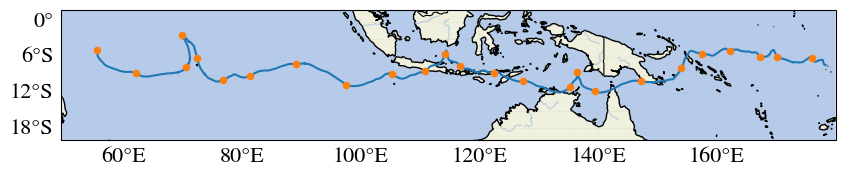

In [44]:
lons = ds['lon'].values
lats = ds['lat'].values

gskw = {"hspace": 0.06, "wspace": 0.05, "height_ratios": [1, 1]}
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 10))

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

# --- Karten-Achse ---
ax_map = fig.add_subplot(1, 1, 1, projection=proj)

ax_map.add_feature(cfeature.LAND, alpha=0.9)
ax_map.add_feature(cfeature.OCEAN, alpha=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
ax_map.add_feature(cfeature.LAKES, alpha=0.6)
ax_map.add_feature(cfeature.RIVERS, alpha=0.5)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
gl.right_labels = False
gl.top_labels = False

ax_map.plot(lons, lats, transform=proj, linewidth=1.5)
ax_map.scatter(lons[::120*24], lats[::120*24], s=20, color="tab:orange", transform=proj, zorder=5)

ax_map.set_ylim([-20,2])

plt.savefig('./figures/1D_Strateole-2_balloon_trajectory.png',dpi=150,bbox_inches="tight",pad_inches=0.05)